# Joint Photometry + Spectroscopy

[`05_fitting_photometry`](05_fitting_photometry.py) showed that broadband
photometry leaves the SFH shape and the metallicity–dust split prior-
dominated. Here we add an optical spectrum covering the metallicity-
sensitive absorption features (Hβ, Mgb, the Fe blends) and fit both datasets
together. The joint posterior is narrower than either single-dataset fit and
pins down parameters photometry alone cannot: the line depths break the
age–metallicity–dust ridge.

Same machinery as the quickstart and notebook 05 (`SEDModel.build`, validated
HMC), with one `Observation` carrying both channels.

In [1]:
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import time
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import tengri
from tengri import (
    FIXED,
    FREE,
    Fixed,
    Observation,
    Photometry,
    SEDModel,
    Spectroscopy,
    Uniform,
    SpectrumPrecomp,
    WavePrecomp,
    builders,
    cosmology,
    load_ssp_data,
    plot,
)
from tengri.inference.fitter import Fitter
from tengri.utils.conversions import lnu_to_fnu

plot.setup_style()
FIG_DIR = Path("_figs")
FIG_DIR.mkdir(exist_ok=True)

C_POST, C_TRUTH, C_DATA, C_SPEC = "#3a76d9", "0.15", "#c3372a", "#d98a3a"

## Observation: photometry + an optical spectrum

Twelve UV–MIR bands (GALEX → WISE) plus an R≈2000 optical spectrum over the
rest-frame 4000–7000 Å window — that covers Hβ, the Mgb triplet, the Fe5270 /
Fe5335 blends, and Hα, the features that carry metallicity and light-weighted
age. We keep the spectrum at 260 pixels: enough to resolve the indices that
break the degeneracy, while keeping the (exact-path) joint forward model fast
enough to fit in a few minutes.

In [2]:
SSP_NAME = "fsps_prsc_miles_chabrier"
ssp_path = Path("../data") / f"{SSP_NAME}.h5"
if not ssp_path.exists():
    ssp_path = Path(tengri.download_ssp(SSP_NAME))
ssp = load_ssp_data(str(ssp_path))

Z_GAL = 0.05
FILTERS = [
    "galex_fuv", "galex_nuv",
    "sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z",
    "2mass_j", "2mass_h", "2mass_ks",
    "wise_w1", "wise_w2",
]
WAVE_OBS = jnp.linspace(4000.0 * (1 + Z_GAL), 7000.0 * (1 + Z_GAL), 260)

phot_obs = Photometry.from_names(FILTERS)
spec_obs = Spectroscopy(wave_obs=WAVE_OBS, resolution=2000)
obs_phot = Observation(photometry=phot_obs)
obs_joint = Observation(photometry=phot_obs, spectroscopy=spec_obs)


def build(obs, approx=None):
    return SEDModel.build(
        ssp_data=ssp,
        observation=obs,
        approx=approx,
        # Free the SFH normalisation + the two timescale parameters; fix the
        # skew/truncation shape nuisances (neither photometry nor a continuum
        # spectrum constrains them, and free they mix poorly under HMC).
        sfh=builders.sfh.tsnorm(
            defaults=FIXED, log_total_mass=FREE, peak_lbt_gyr=FREE, width_gyr=FREE
        ),
        dust=builders.dust.two_component(
            defaults=FIXED,
            law_bc="calzetti",
            tau_bc=Uniform(0.0, 1.0),
            tau_diff=Uniform(0.0, 1.0),
            emission=builders.dust.emission.modified_blackbody(defaults=FIXED),
        ),
        neb=builders.neb.none(),
        stellar={"met_logzsol": Uniform(-1.5, 0.3)},
        redshift=Fixed(Z_GAL),
    )


# Both fits use lookup tables. Photometry-only gets WavePrecomp (SSP × filter
# LUT). The joint model gets SpectrumPrecomp, which builds both LUT families
# side by side — the SSP × filter table for the photometry channel and the
# SSP × pixel table for the spectrum — so neither channel falls back to the
# slow exact wave-grid integration.
model_phot = build(obs_phot, approx=WavePrecomp())
model_joint = build(obs_joint, approx=SpectrumPrecomp())
print(f"Free parameters ({model_joint.spec.n_free}): {', '.join(model_joint.spec.free_params)}")

SSP file already exists at data/fsps_prsc_miles_chabrier.h5; skipping download.


/Users/suchethacooray/.claude-squad/worktrees/cs/olpish-docs_18b4cf0410b66420/src/tengri/parameters/groups.py:568: UserWarning: Parameter 'sfh_tsnorm_skew' was marked FIXED via the '*': FIXED wildcard but its registry default carries no explicit ``default=``. Falling back to the prior midpoint (Array(0., dtype=float64, weak_type=True)); the contract test ``tests/contract/test_param_defaults.py`` should be failing in CI to flag this. Fix: set ``default=<physical_value>`` at the declaration site (e.g. ``Uniform(0, 5, default=2.0)``).
  final_dist, tag = _resolve_value(
/Users/suchethacooray/.claude-squad/worktrees/cs/olpish-docs_18b4cf0410b66420/src/tengri/parameters/groups.py:568: UserWarning: Parameter 'sfh_tsnorm_trunc' was marked FIXED via the '*': FIXED wildcard but its registry default carries no explicit ``default=``. Falling back to the prior midpoint (Array(5.5, dtype=float64, weak_type=True)); the contract test ``tests/contract/test_param_defaults.py`` should be failing in CI t

Free parameters (6): dust_tau_bc, dust_tau_diff, met_logzsol, sfh_tsnorm_log_total_mass, sfh_tsnorm_peak_lbt_gyr, sfh_tsnorm_width_gyr


## Mock data

A single truth (metallicity chosen in the interior of the prior, away from
the edge), and one self-consistent realisation of both channels generated
from the *joint* model so the photometry and spectrum agree by construction.

In [3]:
key = jax.random.PRNGKey(4)
key_mock, key_fit = jax.random.split(key)
truth = model_joint.spec.sample(jax.random.PRNGKey(0))
truth = {
    **truth,
    "met_logzsol": jnp.array(-0.30),
    "dust_tau_bc": jnp.array(0.30),
    "dust_tau_diff": jnp.array(0.25),
    "sfh_tsnorm_log_total_mass": jnp.array(10.5),
}
truth_full = {**model_joint.spec.get_fixed_values(), **{k: float(v) for k, v in truth.items()}}

p_phot = np.asarray(model_joint.predict_photometry(truth_full))
p_spec = np.asarray(model_joint.predict_spectrum(truth_full, wave_obs=WAVE_OBS))
n_phot = p_phot / 20.0          # SNR = 20 photometry
n_spec = p_spec / 30.0          # SNR = 30 per spectral pixel
_rng = np.random.default_rng(0)
flux_phot = p_phot + _rng.normal(size=p_phot.shape) * n_phot
flux_spec = p_spec + _rng.normal(size=p_spec.shape) * n_spec

wave_eff_um = (
    np.array([np.trapezoid(w * t, w) / np.trapezoid(t, w)
              for w, t in zip(phot_obs.filter_waves, phot_obs.filter_trans)]) / 1e4
)
print(f"Truth metallicity log(Z/Zsun) = {float(truth['met_logzsol']):+.2f}")
print(f"Mock: {len(flux_phot)} bands (SNR 20) + {len(flux_spec)}-pixel spectrum (SNR 30/pix)")

Truth metallicity log(Z/Zsun) = -0.30
Mock: 12 bands (SNR 20) + 260-pixel spectrum (SNR 30/pix)


## Two fits: photometry-only, then joint

Both use the same validated HMC recipe (dense mass, n_warmup=1000,
n_leapfrog=20) and both run on lookup tables (WavePrecomp for photometry,
SpectrumPrecomp's dual LUT for the joint fit). The joint fit is still the
slower of the two — it carries the 260-pixel spectral likelihood and its
gradient — at ~10 minutes against the photometry fit's seconds. The two run
sequentially in one process, per the OOM-orchestration rule.

In [4]:
HMC = dict(n_warmup=1000, n_samples=600, n_leapfrog_steps=20,
           dense_mass_matrix=True, target_accept_rate=0.9, key=key_fit)


def run(model, data, noise, data_type, label):
    t0 = time.perf_counter()
    post = Fitter(model, data, noise, data_type=data_type).run("mcmc_hmc", **HMC)
    rmax = max(float(v) for v in post.rhat().values())
    print(f"  {label:12s} {time.perf_counter() - t0:6.0f}s   max R-hat {rmax:.3f}   "
          f"divergences {post.diagnostics.get('n_divergent', 'n/a')}")
    return post


print("Fitting (photometry, then joint):")
post_phot = run(model_phot, flux_phot, n_phot, "photometry", "photometry")
data_joint = np.concatenate([flux_phot, flux_spec])
noise_joint = np.concatenate([n_phot, n_spec])
post_joint = run(model_joint, data_joint, noise_joint, "joint", "joint")

Fitting (photometry, then joint):


/tmp/claude-501/ipykernel_3032/3429541833.py:7: DeprecationWarning: Fitter(sed_model, ...) is deprecated and will be removed in tengri v1.0. Inference is canonically through ForwardModel (issue #211). Replace with: forward = ForwardModel.build(sed=sed_model, observation=obs); Fitter(forward, data, noise).run(method) -- or use the shortcut forward.fit(data, noise, method=...).
  post = Fitter(model, data, noise, data_type=data_type).run("mcmc_hmc", **HMC)


  MAP initialization (200 steps)...


  MAP init done (loss=34.87)


  photometry        5s   max R-hat 1.002   divergences 0


/tmp/claude-501/ipykernel_3032/3429541833.py:7: DeprecationWarning: Fitter(sed_model, ...) is deprecated and will be removed in tengri v1.0. Inference is canonically through ForwardModel (issue #211). Replace with: forward = ForwardModel.build(sed=sed_model, observation=obs); Fitter(forward, data, noise).run(method) -- or use the shortcut forward.fit(data, noise, method=...).
  post = Fitter(model, data, noise, data_type=data_type).run("mcmc_hmc", **HMC)


  MAP initialization (200 steps)...


  MAP init done (loss=601.02)


  joint           525s   max R-hat 1.000   divergences 0


## Constraint widths: joint vs single-modality

The 68% credible width of each free parameter, normalised so the photometry-
only width is 1. Bars below 1 mean the joint fit tightened that parameter.
The largest gains are in metallicity and the dust split.

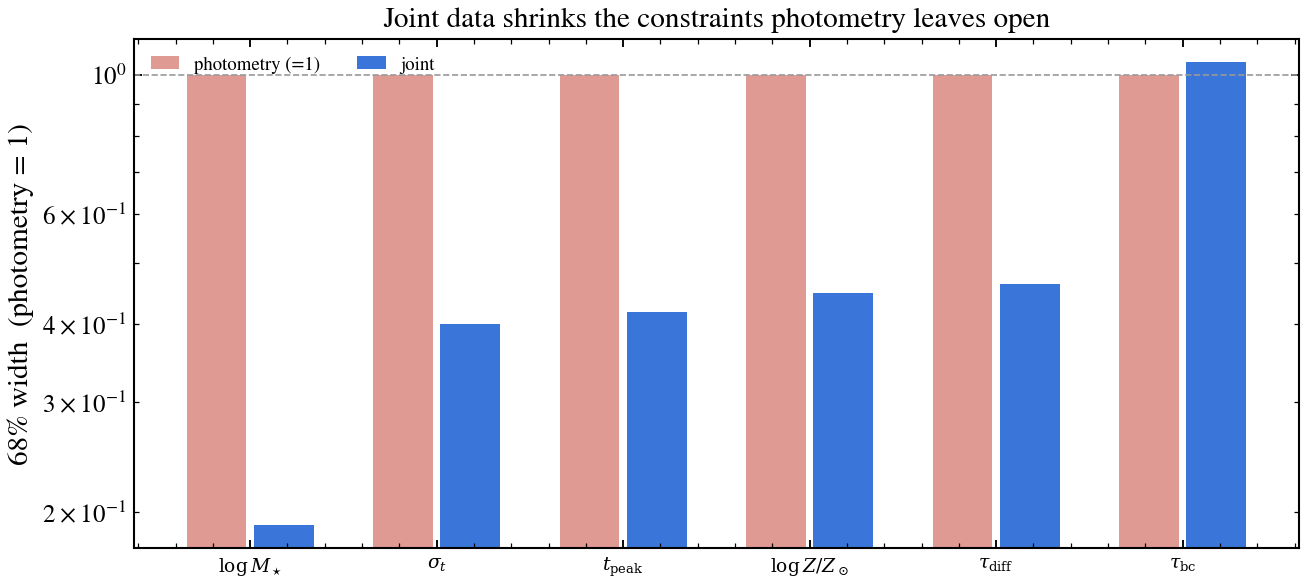

In [5]:
params = model_joint.spec.free_params
labels = {
    "met_logzsol": r"$\log Z/Z_\odot$",
    "dust_tau_bc": r"$\tau_{\rm bc}$",
    "dust_tau_diff": r"$\tau_{\rm diff}$",
    "sfh_tsnorm_log_total_mass": r"$\log M_\star$",
    "sfh_tsnorm_peak_lbt_gyr": r"$t_{\rm peak}$",
    "sfh_tsnorm_width_gyr": r"$\sigma_t$",
    "sfh_tsnorm_skew": "skew",
    "sfh_tsnorm_trunc": "trunc",
}


def width(post, p):
    s = np.asarray(post.samples[p])
    lo, hi = np.percentile(s, [16, 84])
    return hi - lo


w_phot = {p: width(post_phot, p) for p in params}
w_joint = {p: width(post_joint, p) for p in params}

order = sorted(params, key=lambda p: w_joint[p] / w_phot[p])
x = np.arange(len(order))
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.axhline(1.0, color="0.6", lw=0.8, ls="--")
ax.bar(x - 0.18, [1.0 for _ in order], width=0.32, color=C_DATA, alpha=0.5, label="photometry (=1)")
ax.bar(x + 0.18, [w_joint[p] / w_phot[p] for p in order], width=0.32, color=C_POST, label="joint")
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels([labels.get(p, p) for p in order], fontsize=9)
ax.set_ylabel("68% width  (photometry = 1)")
ax.set_title("Joint data shrinks the constraints photometry leaves open")
ax.legend(frameon=False, fontsize=9, ncol=2, loc="upper left")
fig.tight_layout()
fig.savefig(FIG_DIR / "07_constraint_widths.png", dpi=200, bbox_inches="tight")
plt.show()

## Recovery table

Truth vs joint-posterior 16/50/84. With converged chains (R̂ < 1.05) the
intervals are trustworthy; the spectrum pulls metallicity and the dust split
back onto the truth that photometry alone could not separate.

In [6]:
print(f"{'parameter':<28}{'truth':>9}{'p16':>9}{'p50':>9}{'p84':>9}  cover")
print("-" * 66)
n_cov = 0
for p in params:
    s = np.asarray(post_joint.samples[p])
    lo, med, hi = np.percentile(s, [16, 50, 84])
    tv = float(truth_full[p])
    ok = lo <= tv <= hi
    n_cov += ok
    print(f"{p:<28}{tv:>9.3f}{lo:>9.3f}{med:>9.3f}{hi:>9.3f}  {'ok' if ok else 'miss'}")
print(f"\n68% coverage: {n_cov}/{len(params)}")

parameter                       truth      p16      p50      p84  cover
------------------------------------------------------------------
dust_tau_bc                     0.300    0.270    0.515    0.756  ok
dust_tau_diff                   0.250    0.153    0.184    0.217  miss
met_logzsol                    -0.300   -0.320   -0.282   -0.242  ok
sfh_tsnorm_log_total_mass      10.500   10.495   10.500   10.505  ok
sfh_tsnorm_peak_lbt_gyr         2.024    2.077    2.162    2.247  miss
sfh_tsnorm_width_gyr            0.483    0.502    0.525    0.549  miss

68% coverage: 3/6


## Both datasets on one SED

Observed photometry and the optical spectrum on a single F_ν axis, joint
posterior model SED behind them, with the spectral window in an inset. A
single posterior explains the broadband points and the spectrum at the same
time.

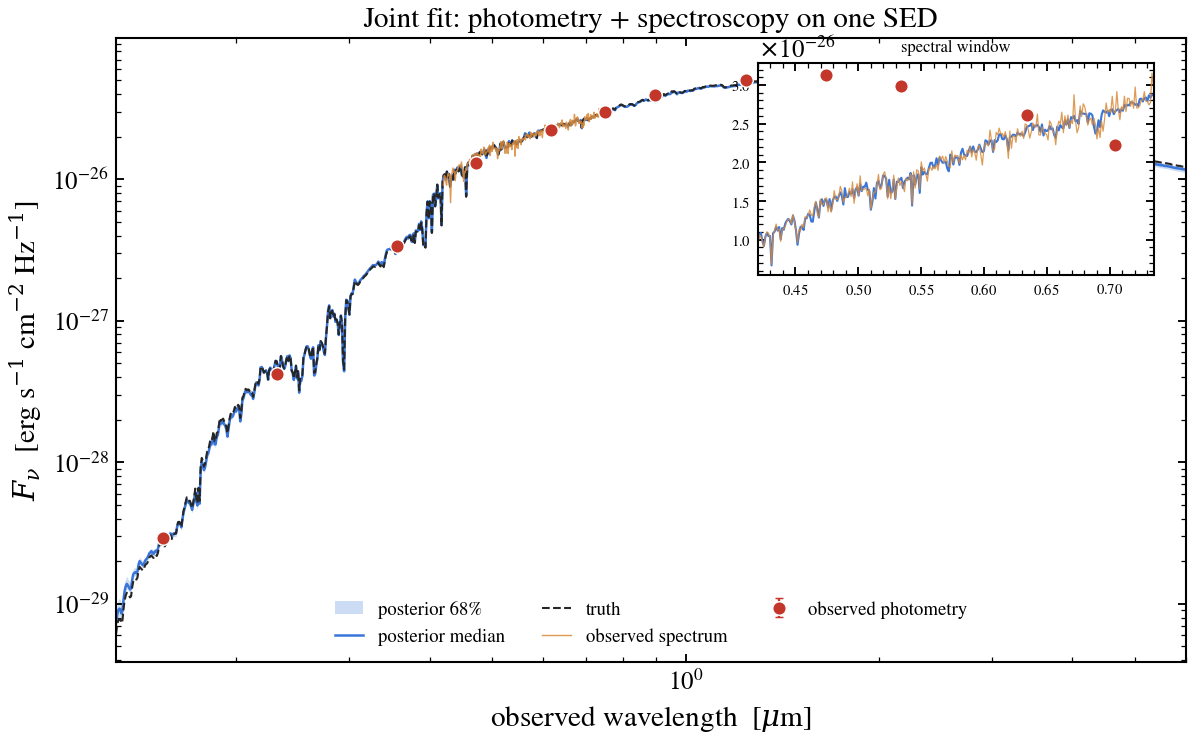

In [7]:
N_DRAW = 60
idx = np.linspace(0, len(next(iter(post_joint.samples.values()))) - 1, N_DRAW).astype(int)
fixed = model_joint.spec.get_fixed_values()
draws = [{**fixed, **{k: float(v[i]) for k, v in post_joint.samples.items()}} for i in idx]

DL = cosmology.luminosity_distance(Z_GAL)
WAVE_FULL = np.geomspace(1300.0, 6.0e4, 1000)
w_full_um = WAVE_FULL / 1e4
w_spec_um = np.asarray(WAVE_OBS) / 1e4


def sed_fnu(p):
    rest = model_joint.predict_rest_sed(p, wave=WAVE_FULL / (1.0 + Z_GAL))
    return np.asarray(lnu_to_fnu(jnp.asarray(rest.sed), DL, Z_GAL))


sed_draws = np.stack([sed_fnu(p) for p in draws])
sed_lo, sed_med, sed_hi = np.percentile(sed_draws, [16, 50, 84], axis=0)
sed_truth = sed_fnu(truth_full)

fig_h, ax = plt.subplots(figsize=(9.2, 5.4))
ax.fill_between(w_full_um, sed_lo, sed_hi, color=C_POST, alpha=0.25, lw=0, label="posterior 68%")
ax.plot(w_full_um, sed_med, color=C_POST, lw=1.2, label="posterior median")
ax.plot(w_full_um, sed_truth, color=C_TRUTH, lw=1.0, ls="--", label="truth")
ax.plot(w_spec_um, flux_spec, color=C_SPEC, lw=0.7, alpha=0.85, zorder=4, label="observed spectrum")
ax.errorbar(wave_eff_um, flux_phot, yerr=n_phot, fmt="o", ms=6.5, color=C_DATA,
            mec="white", mew=0.7, elinewidth=1.1, capsize=2, zorder=6, label="observed photometry")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(w_full_um.min(), w_full_um.max())
ax.set_xlabel(r"observed wavelength  [$\mu$m]")
ax.set_ylabel(r"$F_\nu$  [erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$]")
ax.set_title("Joint fit: photometry + spectroscopy on one SED")
ax.legend(frameon=False, fontsize=9, loc="lower center", ncol=3)

spec_draws_arr = np.stack([np.asarray(model_joint.predict_spectrum(p, wave_obs=WAVE_OBS)) for p in draws])
sp_lo, sp_med, sp_hi = np.percentile(spec_draws_arr, [16, 50, 84], axis=0)
axin = ax.inset_axes([0.60, 0.62, 0.37, 0.34])
axin.fill_between(w_spec_um, sp_lo, sp_hi, color=C_POST, alpha=0.30, lw=0)
axin.plot(w_spec_um, sp_med, color=C_POST, lw=1.0)
axin.plot(w_spec_um, flux_spec, color=C_SPEC, lw=0.6, alpha=0.85)
axin.set_xlim(w_spec_um.min(), w_spec_um.max())
axin.tick_params(labelsize=7)
axin.set_title("spectral window", fontsize=8)
fig_h.savefig(FIG_DIR / "07_joint_sed.png", dpi=300, bbox_inches="tight")
plt.show()

## Corner — joint posterior

Free parameters with truth dashed. The metallicity and dust columns are now
tight and centred on the truth — neither dataset managed that on its own.

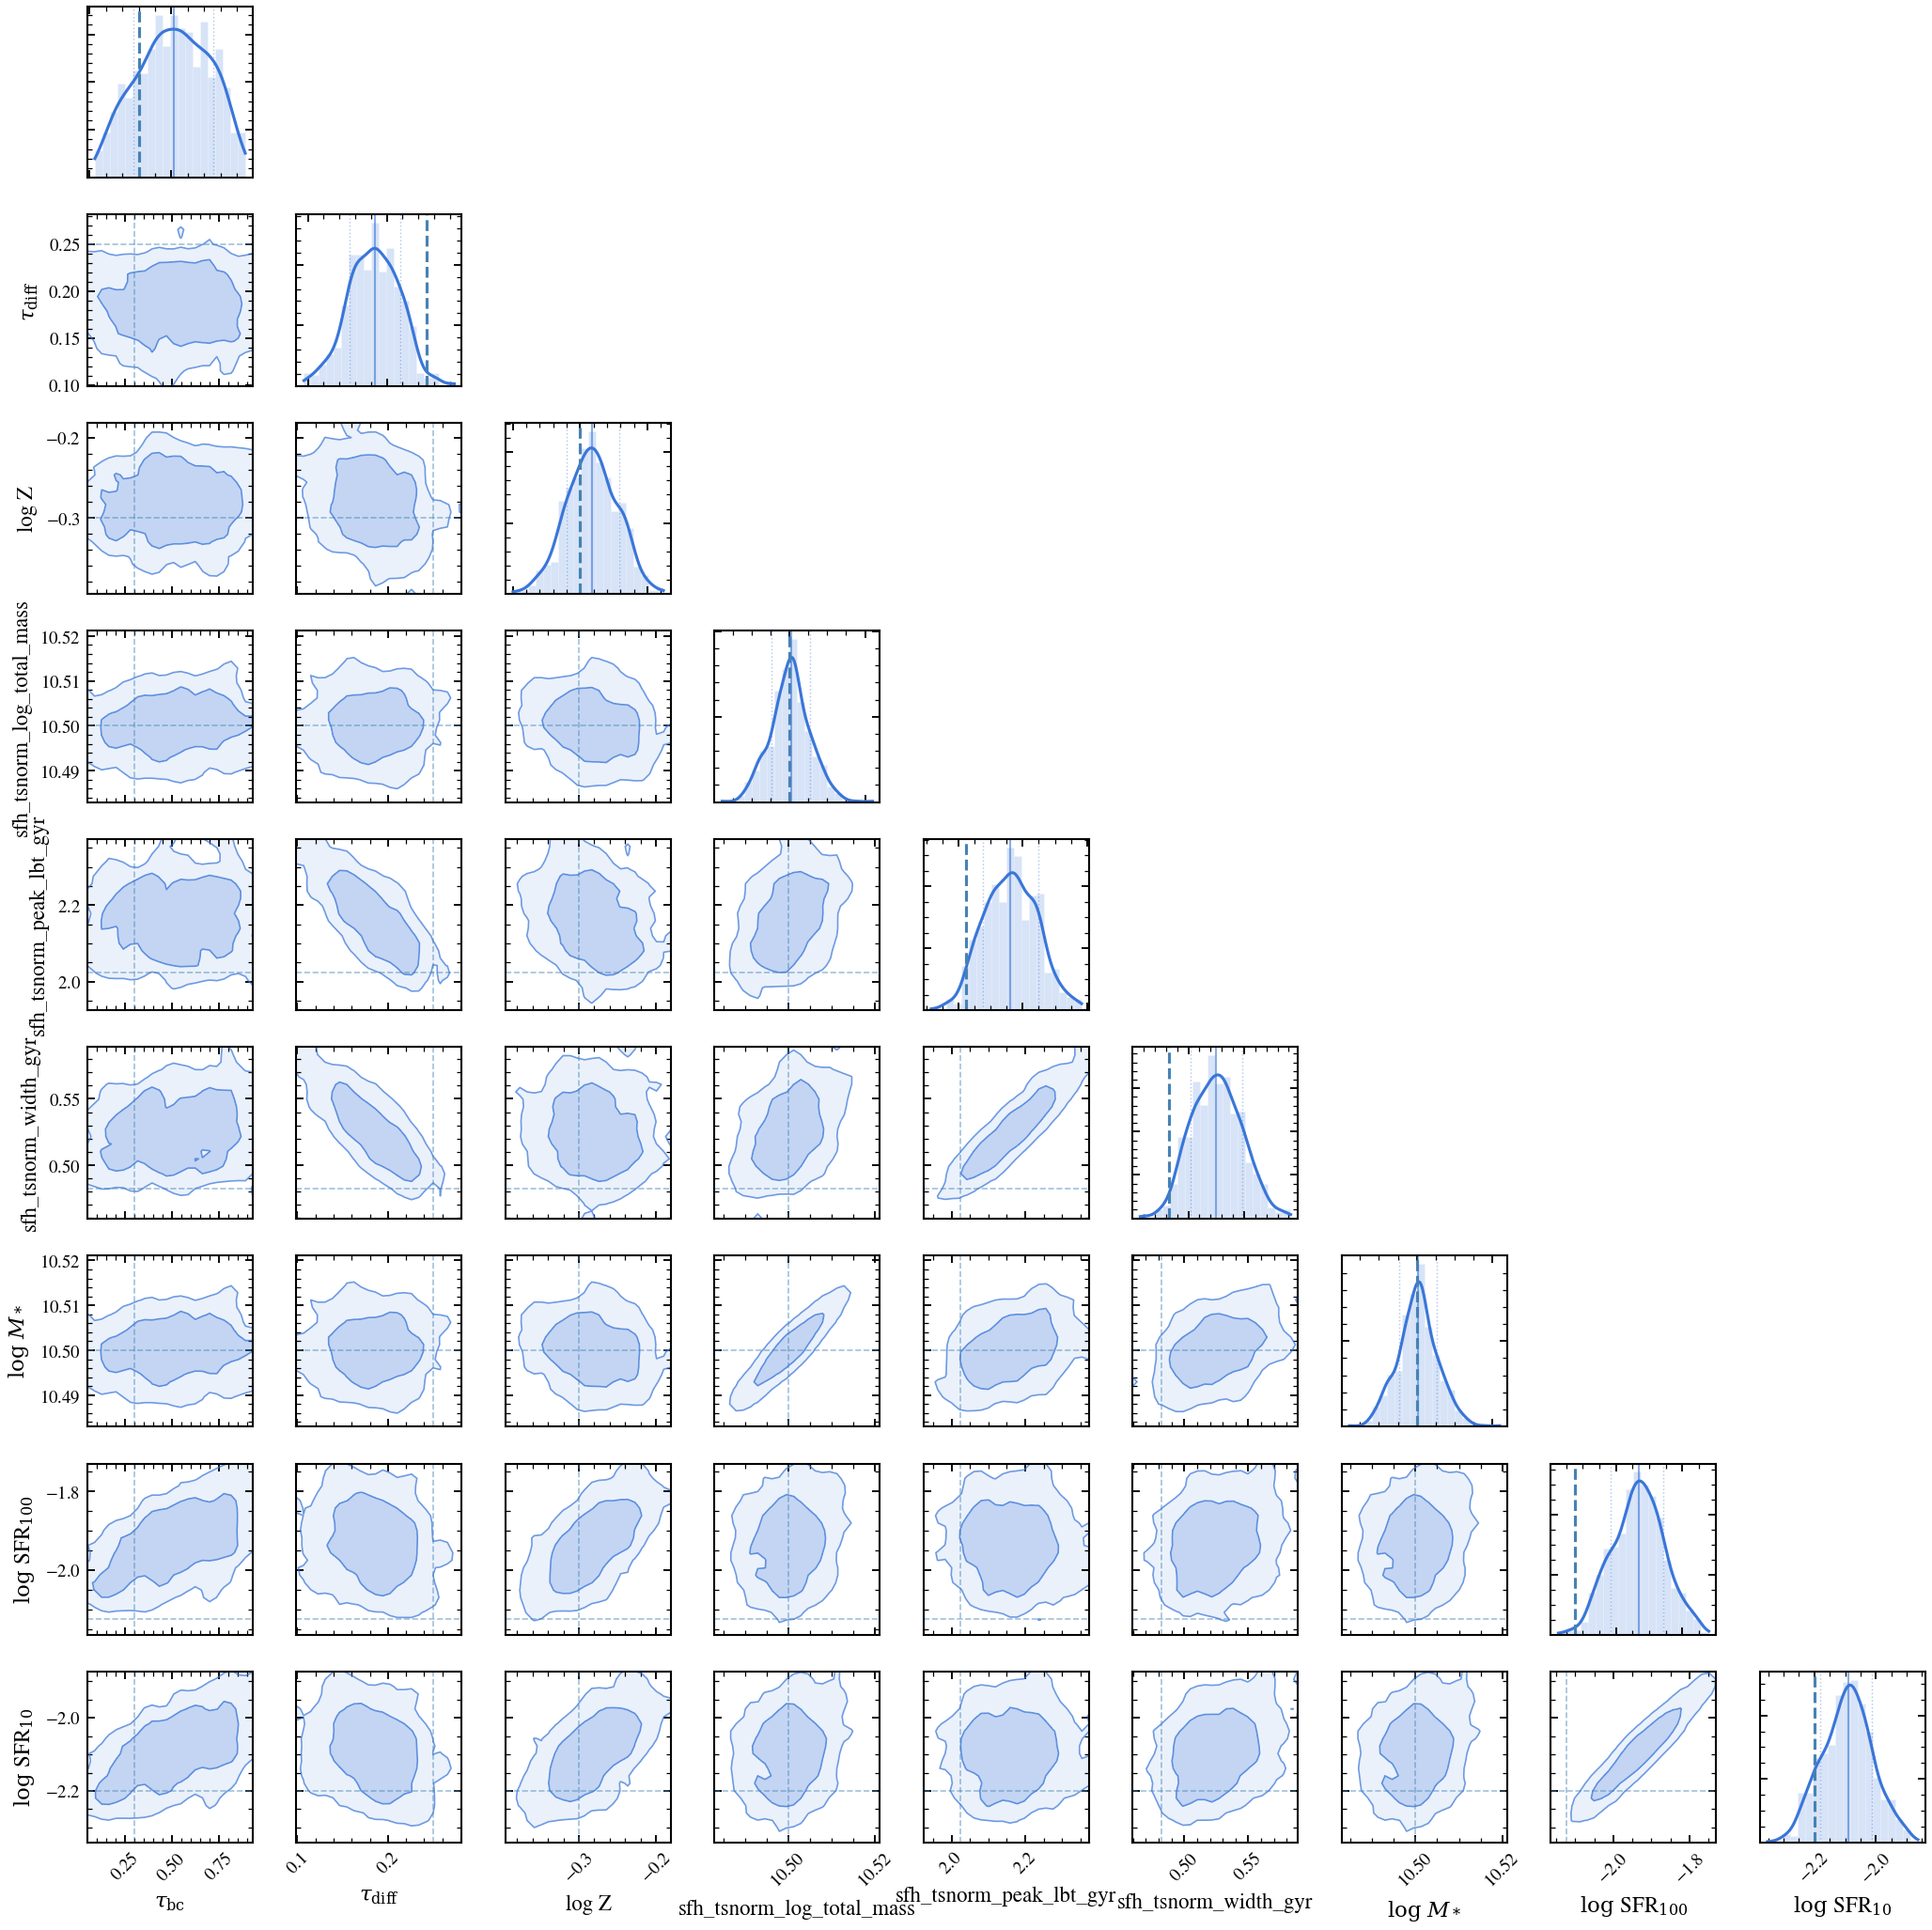

In [8]:
fig_corner = post_joint.plot_corner(truths=truth_full, color=C_POST)
fig_corner.savefig(FIG_DIR / "07_corner.png", dpi=200, bbox_inches="tight")
plt.show()

## Summary

Photometry fixes the overall SED shape and stellar mass; the optical spectrum
adds the absorption-line depths that pin metallicity and the dust split.
Fitted together through one `Observation`, the posterior is narrower than
either alone and recovers the truth the photometry-only fit
([notebook 05](05_fitting_photometry.py)) left degenerate. `SpectrumPrecomp`
runs both channels on lookup tables; the joint fit still takes ~10 minutes,
but the cost is now the per-pixel spectral likelihood and its gradient, not
the forward integration.

In [9]:
from contextlib import suppress

with suppress(Exception):
    tengri.cite(post_joint)

component  name    citation                            
─────────  ──────  ────────────────────────────────────
framework  tengri  Cooray et al. (2026, Paper I)       
ssp        DSPS    Hearin et al. 2023 (MNRAS 521, 1741)
framework  JAX     Bradbury et al. 2018                
[3 results — framework]

% ────────────────────────────────────────────────────────────────
%  Citations for 3 components used by the model.  Paste into your .bib file.
% ────────────────────────────────────────────────────────────────

% [framework] tengri
@article{Cooray_2026,
  author = {{Cooray}, Suchetha},
  title = {{tengri: Differentiable SED fitting with Information-Field-Theory star formation history priors. I. Framework and mock recovery}},
  year = {2026},
  journal = {in preparation},
}

% [ssp] DSPS
@article{Hearin_2023,
  author = {{Hearin}, Andrew P. and {Chaves-Montero}, Jon{\'a}s and {Alarcon}, Alex and {Becker}, Matthew R. and {Benson}, Andrew},
  title = {{DSPS: Differentiable stellar populat